# Best 3 Models Classification: Baseline vs Augmented Data

This notebook compares three strong image classifiers on CIFAR-10 using:
1. Baseline training data
2. Augmented training data

For each model, we track training, validation, and test metrics with **F1 as the main metric**.


## Part 1 - Setup


In [1]:
import os
import copy
import time
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models

SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_WORKERS = 2

# Keep this configurable for faster experiments on weak hardware.
TRAIN_SUBSET_SIZE = None   # e.g. 15000 for faster runs
VAL_SUBSET_SIZE = None     # e.g. 4000
TEST_SUBSET_SIZE = None    # e.g. 5000

CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']
NUM_CLASSES = len(CLASS_NAMES)

print(f"device: {DEVICE}")


def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)


device: cuda


## Part 2 - Data Split and Helpers


In [2]:
# Load once without transform for stratified split.
train_plain = datasets.CIFAR10(root="./data", train=True, download=True)
test_plain = datasets.CIFAR10(root="./data", train=False, download=True)

all_targets = np.array(train_plain.targets)
all_indices = np.arange(len(all_targets))

train_idx, val_idx = train_test_split(
    all_indices,
    test_size=0.2,
    stratify=all_targets,
    random_state=SEED,
)

def stratified_pick(indices, labels, n_samples=None, seed=SEED):
    if n_samples is None or n_samples >= len(indices):
        return indices

    chosen, _ = train_test_split(
        indices,
        train_size=n_samples,
        stratify=labels[indices],
        random_state=seed,
    )
    return chosen

train_idx = stratified_pick(train_idx, all_targets, TRAIN_SUBSET_SIZE)
val_idx = stratified_pick(val_idx, all_targets, VAL_SUBSET_SIZE)

test_targets = np.array(test_plain.targets)
test_indices = np.arange(len(test_targets))
test_idx = stratified_pick(test_indices, test_targets, TEST_SUBSET_SIZE)

print(f"train samples: {len(train_idx)}")
print(f"val samples:   {len(val_idx)}")
print(f"test samples:  {len(test_idx)}")


train samples: 40000
val samples:   10000
test samples:  10000


## Part 3 - Transforms and Augmentation

Augmentation ideas used here include random flip, crop, rotation, affine transforms, and color jitter.


In [3]:
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD = (0.2470, 0.2435, 0.2616)

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

def get_transforms(image_size=224, augmented=False):
    if image_size == 32:
        eval_transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
        ])

        if not augmented:
            train_transform = eval_transform
        else:
            train_transform = transforms.Compose([
                transforms.RandomHorizontalFlip(),
                transforms.RandomCrop(32, padding=4, padding_mode="reflect"),
                transforms.RandomRotation(12),
                transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15, hue=0.03),
                transforms.ToTensor(),
                transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
                transforms.RandomErasing(p=0.2, scale=(0.02, 0.12), ratio=(0.3, 3.3)),
            ])

    else:
        eval_transform = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ])

        if not augmented:
            train_transform = eval_transform
        else:
            train_transform = transforms.Compose([
                transforms.Resize((image_size, image_size)),
                transforms.RandomHorizontalFlip(),
                transforms.RandomCrop(image_size, padding=16, padding_mode="reflect"),
                transforms.RandomRotation(12),
                transforms.RandomAffine(degrees=0, translate=(0.08, 0.08), scale=(0.9, 1.1), shear=8),
                transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.04),
                transforms.ToTensor(),
                transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
                transforms.RandomErasing(p=0.2, scale=(0.02, 0.15), ratio=(0.3, 3.3)),
            ])

    return train_transform, eval_transform


def make_loaders(image_size=224, augmented=False, batch_size=64):
    train_transform, eval_transform = get_transforms(image_size=image_size, augmented=augmented)

    train_ds_full = datasets.CIFAR10(root="./data", train=True, download=False, transform=train_transform)
    val_ds_full = datasets.CIFAR10(root="./data", train=True, download=False, transform=eval_transform)
    test_ds_full = datasets.CIFAR10(root="./data", train=False, download=False, transform=eval_transform)

    train_ds = Subset(train_ds_full, train_idx)
    val_ds = Subset(val_ds_full, val_idx)
    test_ds = Subset(test_ds_full, test_idx)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=NUM_WORKERS)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=NUM_WORKERS)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=NUM_WORKERS)

    return train_loader, val_loader, test_loader


## Part 4 - Top 3 Models

Using three strong models from the previous comparison workflow:
1. SimpleCNN
2. ResNet18
3. EfficientNet-B0


In [4]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


def build_simplecnn(num_classes=10):
    return SimpleCNN(num_classes=num_classes)


def build_resnet18(num_classes=10):
    weights = models.ResNet18_Weights.DEFAULT
    model = models.resnet18(weights=weights)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model


def build_efficientnet_b0(num_classes=10):
    weights = models.EfficientNet_B0_Weights.DEFAULT
    model = models.efficientnet_b0(weights=weights)
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    return model


MODEL_CONFIGS = {
    "SimpleCNN": {
        "builder": build_simplecnn,
        "image_size": 32,
        "batch_size": 128,
        "epochs": 10,
        "lr": 1e-3,
    },
    "ResNet18": {
        "builder": build_resnet18,
        "image_size": 224,
        "batch_size": 64,
        "epochs": 6,
        "lr": 1e-4,
    },
    "EfficientNet-B0": {
        "builder": build_efficientnet_b0,
        "image_size": 224,
        "batch_size": 64,
        "epochs": 6,
        "lr": 1e-4,
    },
}


## Part 5 - Training and Evaluation Functions


In [5]:
def cls_metrics(y_true, y_pred, average="weighted"):
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average=average, zero_division=0
    )
    acc = accuracy_score(y_true, y_pred)
    return {
        "acc": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }


def run_one_epoch(model, loader, criterion, optimizer=None, device=DEVICE):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    running_loss = 0.0
    all_preds, all_labels = [], []

    context = torch.enable_grad() if is_train else torch.no_grad()
    with context:
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            if is_train:
                optimizer.zero_grad()

            logits = model(x)
            loss = criterion(logits, y)

            if is_train:
                loss.backward()
                optimizer.step()

            running_loss += loss.item() * x.size(0)
            preds = logits.argmax(dim=1)
            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(y.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    metrics = cls_metrics(all_labels, all_preds)
    return epoch_loss, metrics, np.array(all_labels), np.array(all_preds)


def fit_model(model, train_loader, val_loader, epochs, lr, weight_decay=1e-4, device=DEVICE):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    history = {
        "train_loss": [], "val_loss": [],
        "train_acc": [], "val_acc": [],
        "train_precision": [], "val_precision": [],
        "train_recall": [], "val_recall": [],
        "train_f1": [], "val_f1": [],
    }

    best_state = None
    best_val_f1 = -1

    for epoch in range(epochs):
        train_loss, train_metrics, _, _ = run_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_metrics, _, _ = run_one_epoch(model, val_loader, criterion, None, device)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        for m in ["acc", "precision", "recall", "f1"]:
            history[f"train_{m}"] .append(train_metrics[m])
            history[f"val_{m}"] .append(val_metrics[m])

        if val_metrics["f1"] > best_val_f1:
            best_val_f1 = val_metrics["f1"]
            best_state = copy.deepcopy(model.state_dict())

        print(
            f"Epoch {epoch+1:02d}/{epochs} | "
            f"train_f1={train_metrics['f1']:.4f} | "
            f"val_f1={val_metrics['f1']:.4f} | "
            f"val_acc={val_metrics['acc']:.4f}"
        )

    model.load_state_dict(best_state)
    return model, history


def evaluate_split(model, loader, device=DEVICE):
    criterion = nn.CrossEntropyLoss()
    loss, metrics, y_true, y_pred = run_one_epoch(model, loader, criterion, None, device)
    cm = confusion_matrix(y_true, y_pred)
    return loss, metrics, y_true, y_pred, cm


def run_experiment(experiment_name, augmented=False):
    results = []
    histories = {}
    confusion_maps = {}
    predictions = {}

    print(f"\nExperiment: {experiment_name}")

    for model_name, cfg in MODEL_CONFIGS.items():
        print(f"\n{model_name}")

        train_loader, val_loader, test_loader = make_loaders(
            image_size=cfg["image_size"],
            augmented=augmented,
            batch_size=cfg["batch_size"],
        )

        model = cfg["builder"](num_classes=NUM_CLASSES)

        start = time.time()
        model, history = fit_model(
            model,
            train_loader,
            val_loader,
            epochs=cfg["epochs"],
            lr=cfg["lr"],
            device=DEVICE,
        )
        train_time = time.time() - start

        _, train_metrics, _, _, _ = evaluate_split(model, train_loader)
        _, val_metrics, _, _, _ = evaluate_split(model, val_loader)
        _, test_metrics, y_test, y_pred, cm = evaluate_split(model, test_loader)

        row = {
            "experiment": experiment_name,
            "model": model_name,
            "train_time_sec": train_time,

            "best_train_f1_epoch": float(np.max(history["train_f1"])),
            "best_val_f1_epoch": float(np.max(history["val_f1"])),

            "train_acc": train_metrics["acc"],
            "train_precision": train_metrics["precision"],
            "train_recall": train_metrics["recall"],
            "train_f1": train_metrics["f1"],

            "val_acc": val_metrics["acc"],
            "val_precision": val_metrics["precision"],
            "val_recall": val_metrics["recall"],
            "val_f1": val_metrics["f1"],

            "test_acc": test_metrics["acc"],
            "test_precision": test_metrics["precision"],
            "test_recall": test_metrics["recall"],
            "test_f1": test_metrics["f1"],
        }

        results.append(row)
        histories[(experiment_name, model_name)] = history
        confusion_maps[(experiment_name, model_name)] = cm
        predictions[(experiment_name, model_name)] = (y_test, y_pred)

        print(
            f"{model_name} done | val_f1={val_metrics['f1']:.4f} | "
            f"test_f1={test_metrics['f1']:.4f}"
        )

    results_df = pd.DataFrame(results).sort_values(["experiment", "test_f1"], ascending=[True, False])
    return results_df, histories, confusion_maps, predictions


## Part 6 - Baseline (No Augmentation)


In [6]:
baseline_results, baseline_histories, baseline_cms, baseline_preds = run_experiment(
    experiment_name="baseline",
    augmented=False,
)

baseline_results.sort_values("test_f1", ascending=False)



Experiment: baseline

SimpleCNN
Epoch 01/10 | train_f1=0.5096 | val_f1=0.6031 | val_acc=0.6090
Epoch 02/10 | train_f1=0.6594 | val_f1=0.6971 | val_acc=0.6970
Epoch 03/10 | train_f1=0.7097 | val_f1=0.6686 | val_acc=0.6798
Epoch 04/10 | train_f1=0.7394 | val_f1=0.7349 | val_acc=0.7323
Epoch 05/10 | train_f1=0.7671 | val_f1=0.7479 | val_acc=0.7479
Epoch 06/10 | train_f1=0.7890 | val_f1=0.7493 | val_acc=0.7494
Epoch 07/10 | train_f1=0.8066 | val_f1=0.7713 | val_acc=0.7748
Epoch 08/10 | train_f1=0.8197 | val_f1=0.7574 | val_acc=0.7616
Epoch 09/10 | train_f1=0.8392 | val_f1=0.7679 | val_acc=0.7686
Epoch 10/10 | train_f1=0.8493 | val_f1=0.7689 | val_acc=0.7693
SimpleCNN done | val_f1=0.7713 | test_f1=0.7616

ResNet18
Epoch 01/6 | train_f1=0.8840 | val_f1=0.9292 | val_acc=0.9293
Epoch 02/6 | train_f1=0.9686 | val_f1=0.9349 | val_acc=0.9347
Epoch 03/6 | train_f1=0.9880 | val_f1=0.9259 | val_acc=0.9253
Epoch 04/6 | train_f1=0.9915 | val_f1=0.9390 | val_acc=0.9389
Epoch 05/6 | train_f1=0.9912 | 

,experiment,model,train_time_sec,best_train_f1_epoch,best_val_f1_epoch,train_acc,train_precision,train_recall,train_f1,val_acc,val_precision,val_recall,val_f1,test_acc,test_precision,test_recall,test_f1
2,baseline,EfficientNet-B0,452.240914,0.988625,0.962883,0.998450,0.998450,0.998450,0.998450,0.9629,0.962944,0.9629,0.962883,0.9614,0.961395,0.9614,0.961340
1,baseline,ResNet18,292.363691,0.991549,0.938966,0.994700,0.994741,0.994700,0.994693,0.9389,0.939805,0.9389,0.938966,0.9353,0.936097,0.9353,0.935300
0,baseline,SimpleCNN,113.578240,0.849282,0.771334,0.856975,0.856952,0.856975,0.853655,0.7748,0.773277,0.7748,0.771334,0.7668,0.764104,0.7668,0.761554


## Part 7 - Augmented Data Training


In [7]:
aug_results, aug_histories, aug_cms, aug_preds = run_experiment(
    experiment_name="augmented",
    augmented=True,
)

aug_results.sort_values("test_f1", ascending=False)



Experiment: augmented

SimpleCNN
Epoch 01/10 | train_f1=0.4133 | val_f1=0.5588 | val_acc=0.5597
Epoch 02/10 | train_f1=0.5327 | val_f1=0.6056 | val_acc=0.6143
Epoch 03/10 | train_f1=0.5801 | val_f1=0.6484 | val_acc=0.6418
Epoch 04/10 | train_f1=0.6086 | val_f1=0.6606 | val_acc=0.6746
Epoch 05/10 | train_f1=0.6276 | val_f1=0.7097 | val_acc=0.7028
Epoch 06/10 | train_f1=0.6451 | val_f1=0.7025 | val_acc=0.7092
Epoch 07/10 | train_f1=0.6611 | val_f1=0.7109 | val_acc=0.7132
Epoch 08/10 | train_f1=0.6712 | val_f1=0.7361 | val_acc=0.7419
Epoch 09/10 | train_f1=0.6814 | val_f1=0.7621 | val_acc=0.7608
Epoch 10/10 | train_f1=0.6895 | val_f1=0.7502 | val_acc=0.7556
SimpleCNN done | val_f1=0.7621 | test_f1=0.7576

ResNet18
Epoch 01/6 | train_f1=0.8433 | val_f1=0.9258 | val_acc=0.9254
Epoch 02/6 | train_f1=0.9141 | val_f1=0.9304 | val_acc=0.9304
Epoch 03/6 | train_f1=0.9325 | val_f1=0.9461 | val_acc=0.9462
Epoch 04/6 | train_f1=0.9441 | val_f1=0.9437 | val_acc=0.9433
Epoch 05/6 | train_f1=0.9491 |

,experiment,model,train_time_sec,best_train_f1_epoch,best_val_f1_epoch,train_acc,train_precision,train_recall,train_f1,val_acc,val_precision,val_recall,val_f1,test_acc,test_precision,test_recall,test_f1
2,augmented,EfficientNet-B0,435.981573,0.967850,0.965148,0.986150,0.986173,0.986150,0.986143,0.9652,0.965181,0.9652,0.965148,0.9609,0.960936,0.9609,0.960841
1,augmented,ResNet18,429.879127,0.957231,0.948592,0.966575,0.966731,0.966575,0.966550,0.9486,0.949139,0.9486,0.948592,0.9475,0.947996,0.9475,0.947491
0,augmented,SimpleCNN,188.830291,0.689534,0.762066,0.708200,0.718411,0.708200,0.710644,0.7608,0.769253,0.7608,0.762066,0.7571,0.763583,0.7571,0.757556


## Part 8 - Compare Baseline vs Augmented


In [8]:
all_results = pd.concat([baseline_results, aug_results], ignore_index=True)
all_results = all_results.sort_values(["experiment", "test_f1"], ascending=[True, False])
all_results


,experiment,model,train_time_sec,best_train_f1_epoch,best_val_f1_epoch,train_acc,train_precision,train_recall,train_f1,val_acc,val_precision,val_recall,val_f1,test_acc,test_precision,test_recall,test_f1
3,augmented,EfficientNet-B0,435.981573,0.967850,0.965148,0.986150,0.986173,0.986150,0.986143,0.9652,0.965181,0.9652,0.965148,0.9609,0.960936,0.9609,0.960841
4,augmented,ResNet18,429.879127,0.957231,0.948592,0.966575,0.966731,0.966575,0.966550,0.9486,0.949139,0.9486,0.948592,0.9475,0.947996,0.9475,0.947491
5,augmented,SimpleCNN,188.830291,0.689534,0.762066,0.708200,0.718411,0.708200,0.710644,0.7608,0.769253,0.7608,0.762066,0.7571,0.763583,0.7571,0.757556
0,baseline,EfficientNet-B0,452.240914,0.988625,0.962883,0.998450,0.998450,0.998450,0.998450,0.9629,0.962944,0.9629,0.962883,0.9614,0.961395,0.9614,0.961340
1,baseline,ResNet18,292.363691,0.991549,0.938966,0.994700,0.994741,0.994700,0.994693,0.9389,0.939805,0.9389,0.938966,0.9353,0.936097,0.9353,0.935300
2,baseline,SimpleCNN,113.578240,0.849282,0.771334,0.856975,0.856952,0.856975,0.853655,0.7748,0.773277,0.7748,0.771334,0.7668,0.764104,0.7668,0.761554


In [9]:
compare_cols = ["experiment", "model", "train_f1", "val_f1", "test_f1", "test_precision", "test_recall", "test_acc"]
comparison = all_results[compare_cols].copy()
comparison


,experiment,model,train_f1,val_f1,test_f1,test_precision,test_recall,test_acc
3,augmented,EfficientNet-B0,0.986143,0.965148,0.960841,0.960936,0.9609,0.9609
4,augmented,ResNet18,0.966550,0.948592,0.947491,0.947996,0.9475,0.9475
5,augmented,SimpleCNN,0.710644,0.762066,0.757556,0.763583,0.7571,0.7571
0,baseline,EfficientNet-B0,0.998450,0.962883,0.961340,0.961395,0.9614,0.9614
1,baseline,ResNet18,0.994693,0.938966,0.935300,0.936097,0.9353,0.9353
2,baseline,SimpleCNN,0.853655,0.771334,0.761554,0.764104,0.7668,0.7668


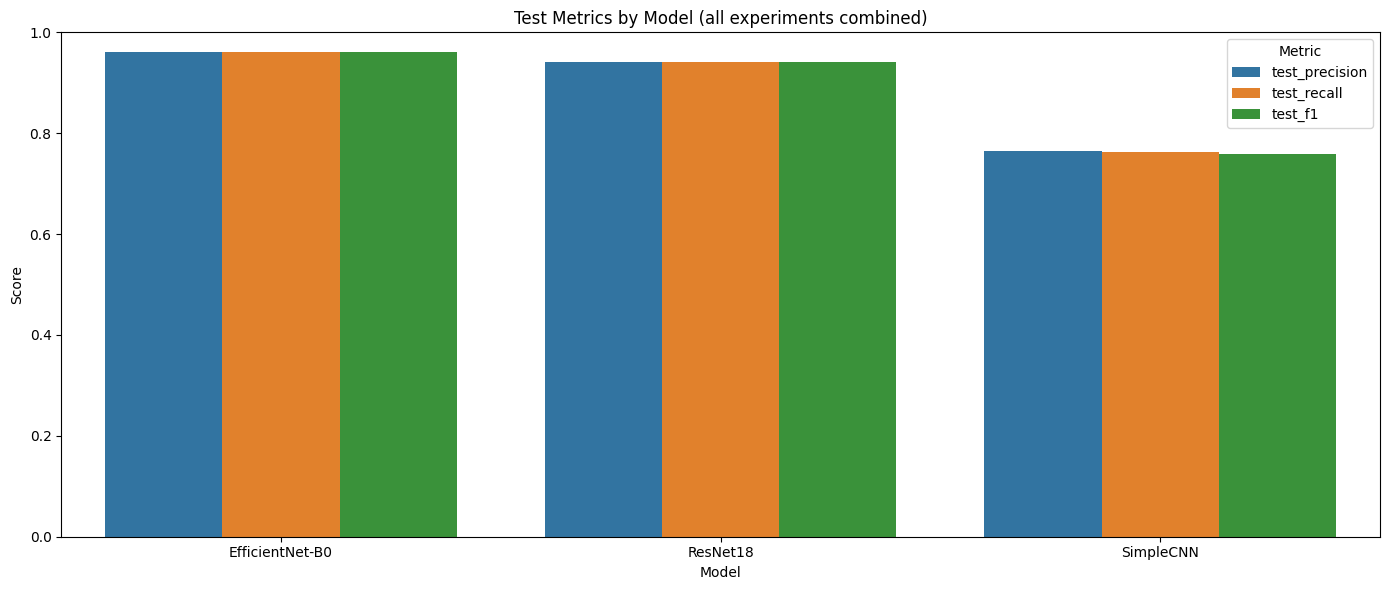

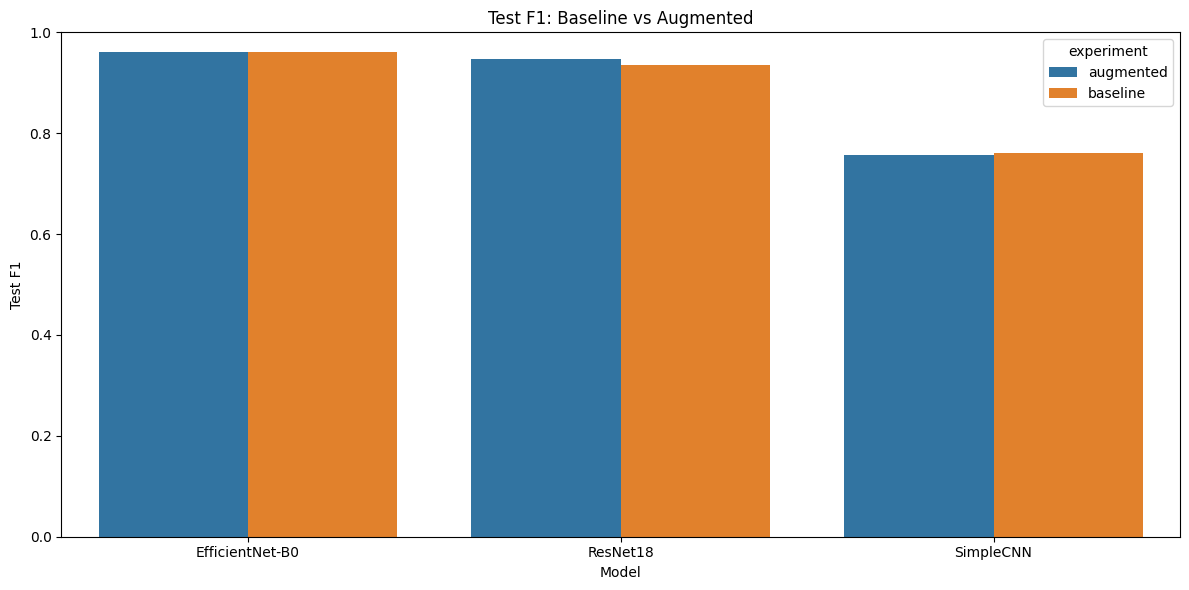

In [10]:
plot_df = all_results[["experiment", "model", "test_precision", "test_recall", "test_f1"]].melt(
    id_vars=["experiment", "model"],
    var_name="metric",
    value_name="score",
)

plt.figure(figsize=(14, 6))
sns.barplot(data=plot_df, x="model", y="score", hue="metric", ci=None)
plt.title("Test Metrics by Model (all experiments combined)")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(data=all_results, x="model", y="test_f1", hue="experiment", ci=None)
plt.title("Test F1: Baseline vs Augmented")
plt.xlabel("Model")
plt.ylabel("Test F1")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


## Part 9 - Best Model Reports (Per Experiment)


In [11]:
def print_best_report(results_df, pred_map, experiment_name):
    best_row = results_df.sort_values("test_f1", ascending=False).iloc[0]
    best_model = best_row["model"]
    y_true, y_pred = pred_map[(experiment_name, best_model)]

    print(f"{experiment_name} best model by test F1: {best_model}")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))


print_best_report(baseline_results, baseline_preds, "baseline")
print_best_report(aug_results, aug_preds, "augmented")


baseline best model by test F1: EfficientNet-B0
              precision    recall  f1-score   support

    airplane       0.96      0.96      0.96      1000
  automobile       0.96      0.98      0.97      1000
        bird       0.97      0.95      0.96      1000
         cat       0.93      0.92      0.92      1000
        deer       0.96      0.96      0.96      1000
         dog       0.93      0.94      0.94      1000
        frog       0.98      0.98      0.98      1000
       horse       0.97      0.98      0.98      1000
        ship       0.97      0.99      0.98      1000
       truck       0.98      0.96      0.97      1000

    accuracy                           0.96     10000
   macro avg       0.96      0.96      0.96     10000
weighted avg       0.96      0.96      0.96     10000

augmented best model by test F1: EfficientNet-B0
              precision    recall  f1-score   support

    airplane       0.96      0.97      0.96      1000
  automobile       0.97      0.98  

### Note: ResNet18 and EfficientNet-80 pretrained on ImageNet-1K, but not specifically on CIFAR-10.